In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [1]:
import os

train_path = "../data/train"

print("Current Working Directory:", os.getcwd())
print("Train Folder Exists:", os.path.exists(train_path))
print("Number of Images:", len(os.listdir(train_path)))
print("First 10 Images:")
print(os.listdir(train_path)[:10])

Current Working Directory: c:\Users\thode\OneDrive\SCT_ML_Task03_CatDogClassification\notebook
Train Folder Exists: True
Number of Images: 25000
First 10 Images:
['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg']


In [2]:
IMG_SIZE = 64

In [3]:
data = []
labels = []

In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 64
data = []
labels = []

train_path = "../data/train"

files = os.listdir(train_path)[:100]

for image in tqdm(files):
    img_path = os.path.join(train_path, image)

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    data.append(img.flatten())

    if image.startswith("cat"):
        labels.append(0)
    else:
        labels.append(1)

print("Loaded:", len(data))

100%|██████████| 100/100 [00:00<00:00, 1615.87it/s]

Loaded: 100


In [7]:
X = np.array(data)
y = np.array(labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 4096)
Shape of y: (100,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (80, 4096)
Testing samples: (20, 4096)


In [ ]:
import os
import random
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 64
data = []
labels = []

train_path = "../data/train"

# Get all image files
files = os.listdir(train_path)

# Shuffle them randomly
random.seed(42)
random.shuffle(files)

# Take only the first 1000 shuffled images
files = files[:1000]

for image in tqdm(files):
    img_path = os.path.join(train_path, image)

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    data.append(img.flatten())

    if image.startswith("cat"):
        labels.append(0)
    else:
        labels.append(1)

print("Images Loaded:", len(data))
print("Cats:", labels.count(0))
print("Dogs:", labels.count(1))

100%|██████████| 100/100 [00:00<00:00, 896.85it/s]

Images Loaded: 100
Cats: 40
Dogs: 60


In [12]:
X = np.array(data)
y = np.array(labels)

print(X.shape)
print(y.shape)

(100, 4096)
(100,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.svm import SVC

model = SVC(kernel="linear", random_state=42)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.35


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.22      0.25      0.24         8
           1       0.45      0.42      0.43        12

    accuracy                           0.35        20
   macro avg       0.34      0.33      0.34        20
weighted avg       0.36      0.35      0.35        20



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2 6]
 [7 5]]


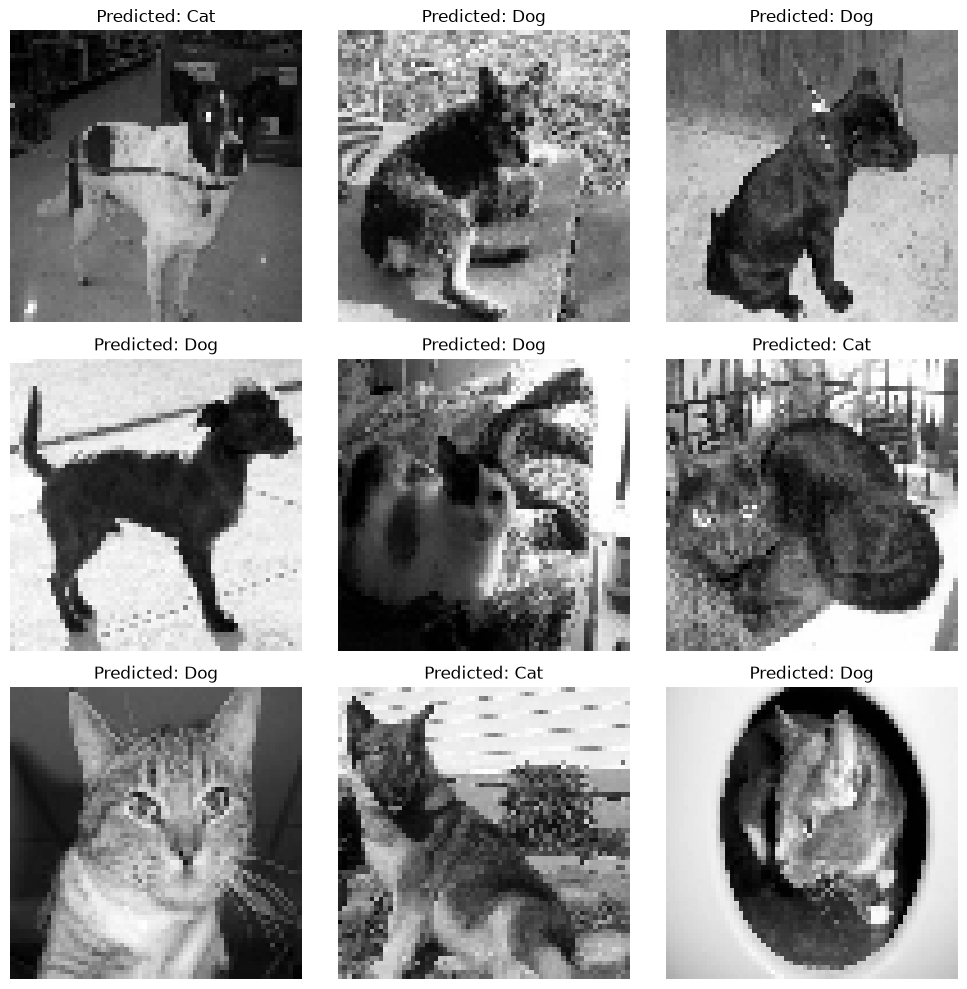

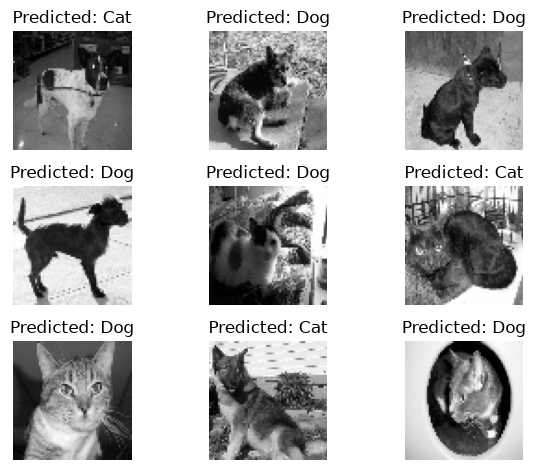

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i].reshape(64, 64), cmap="gray")

    if y_pred[i] == 0:
        plt.title("Predicted: Cat")
    else:
        plt.title("Predicted: Dog")

    plt.axis("off")

plt.tight_layout()
plt.show()

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_test[i].reshape(64, 64), cmap="gray")

    if y_pred[i] == 0:
        plt.title("Predicted: Cat")
    else:
        plt.title("Predicted: Dog")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/svm_cat_dog.pkl")

print("Model saved successfully!")

Model saved successfully!
